# Laboratory Day 7: Segmentation

## 1. Threshold-based Method
**Exercise 1.1 (10 points)**: Implement Otsu's method. Suggested steps:
- For gray values in range of [0, 255]. Compute L as the total number of possible gray values.
- Select $k=1, ..., L$, compute $\sigma_B^2(k)$, which is shown in the lecture
- Select the $k^*$ such that $\sigma_B^2(k^*)$ is a global maximum.

In [4]:
#!pip install scikit-image
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.segmentation import slic, mark_boundaries

In [3]:
def otsu_method(image:np.array)-> int:
  pixels = image.flatten()

  # calculating color posibilities and sum them up
  hist, bins = np.histogram(pixels, bins=256, range=[0,256])
  hist_norm = hist / hist.sum()
  total_pixels = pixels.size

  # calculating mean of intensity over the whole image
  total_mean = np.sum(np.arange(256) * hist_norm)

  # setting base
  max_sigma_b_squared = 0
  optimal_threshold = 0
  sum_background = 0
  count_background = 0

  for k in range(256):

    count_background += hist[k]
    sum_background += k * hist[k]

    if count_background == 0 or count_background == total_pixels:
      continue

    # weight background classes
    w_b = count_background / total_pixels
    # weight forderground pixels
    w_f = (total_pixels - count_background) / total_pixels
    # medium value background class
    mu_b = sum_background / count_background
    # medium intensity of forground
    mu_f = (total_mean * total_pixels - sum_background) / (total_pixels - count_background)
    # inter class varianz
    sigma_b_squared = w_b * w_f * ((mu_b - mu_f) ** 2)

    # caltculating optimal treshold for inter clases variance
    if sigma_b_squared > max_sigma_b_squared:
      max_sigma_b_squared = sigma_b_squared
      optimal_threshold = k
  return optimal_threshold

**Exercise 1.2 (5 points)**
- Apply the implemented Otsu's method to image "cell.jpg".
- Visualize the foreground and background after the separation.

Optimal threshold found by Otsu's method: 204


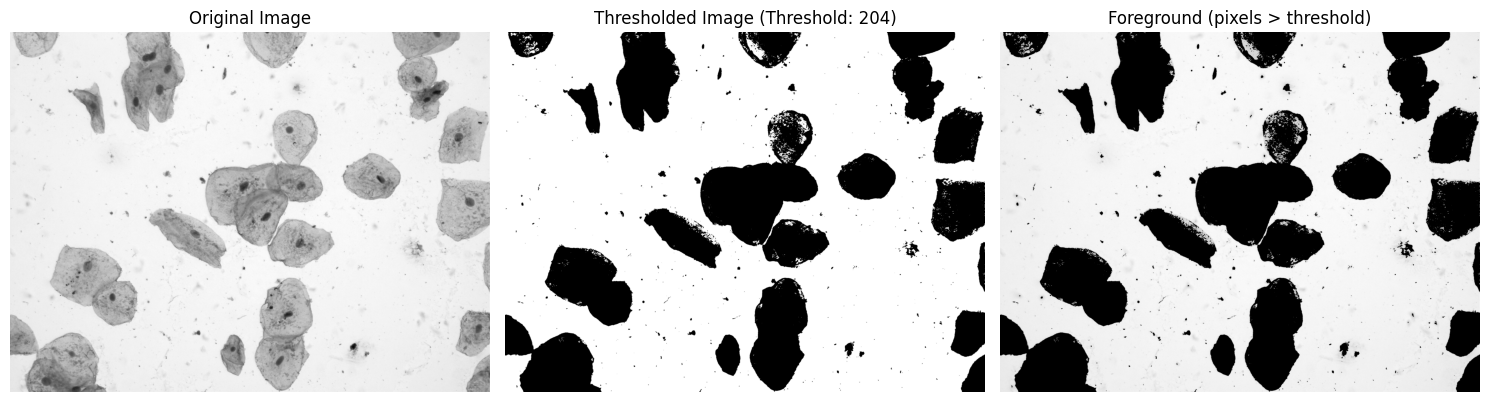

In [9]:
import cv2

# Load the image
image_path = '/content/cell.jpg'
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)


# Apply Otsu's method
optimal_threshold = otsu_method(image)
print(f"Optimal threshold found by Otsu's method: {optimal_threshold}")

# Create binary image
binary_image = (image > optimal_threshold).astype(np.uint8) * 255

# Visualize the results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(binary_image, cmap='gray')
plt.title(f'Thresholded Image (Threshold: {optimal_threshold})')
plt.axis('off')

plt.subplot(1, 3, 3)
# Display foreground (white) and background (black)
foreground = np.where(image > optimal_threshold, image, 0)
background = np.where(image <= optimal_threshold, image, 0)


plt.imshow(foreground, cmap='gray')
plt.title('Foreground (pixels > threshold)')
plt.axis('off')

plt.tight_layout()
plt.show()

# 2. K-Means Clustering

**Exercise 2.1 (10 points)**
Implement k-means algorithm by yourself. Denote $x \in \mathbb{R}^{N \times D}$ as a given data set, where $N$ is the total number of points and $D$ is the number of features. Denote $K$ as a given integer for $K$-means clustering, $K\geq 2$. Denote $\mu \in \mathbb{R}^{K \times D}$ as initial values of central points of each clusters.

Implement the function

     my_k_means(x: np.ndarray, K: int, mu: np.ndarray, maxIteration: int),

which return a np.ndarray with length $N$ containing the cluster index of each point.


K-Means algorithm takes the following steps:
- Step 1: Update clustering assignment of each data point
- Step 2: Update $\mu$
- Step 3: Go to step 1, if stop condition is not fulfilled





In [13]:
def my_k_means(x: np.ndarray, K: int, mu: np.ndarray, maxIteration: int):
    N, D = x.shape
    # Ensure initial centroids have the correct shape (K, D)
    if mu.shape != (K, D):
        raise ValueError(f"Initial centroids mu must have shape ({K}, {D}), but got {mu.shape}")

    # Initialize cluster
    cluster_assignments = np.zeros(N, dtype=int)

    for iteration in range(maxIteration):

        new_cluster_assignments = np.zeros(N, dtype=int)
        for i in range(N):
            distances = np.linalg.norm(x[i] - mu, axis=1)
            new_cluster_assignments[i] = np.argmin(distances)

        # Check for convergence
        if np.array_equal(new_cluster_assignments, cluster_assignments):
            print(f"K-means converged after {iteration + 1} iterations.")
            break

        cluster_assignments = new_cluster_assignments

        # Update mu
        for k in range(K):
            points_in_cluster = x[cluster_assignments == k]
            if len(points_in_cluster) > 0:
                mu[k] = np.mean(points_in_cluster, axis=0)


    return cluster_assignments

**Exercise 2.2 (5 points)**
- Choose $K =2$,  $\mu_0 = [[100, 100, 100], [200, 200, 200]]$ as initial values. Apply the developed k-means algorithm to the image "single_cell.png" in RGB.

- Generate an image mask of the clustering results and visualize the results.

- Choose $K =2$,  $\mu_0 = [100, 200]$ as initial values. Apply the developed k-means algorithm to the image "single_cell.png" in gray scale.

- Generate an image mask of the clustering results and visualize the results.

Applying K-Means to RGB image...
K-means converged after 10 iterations.


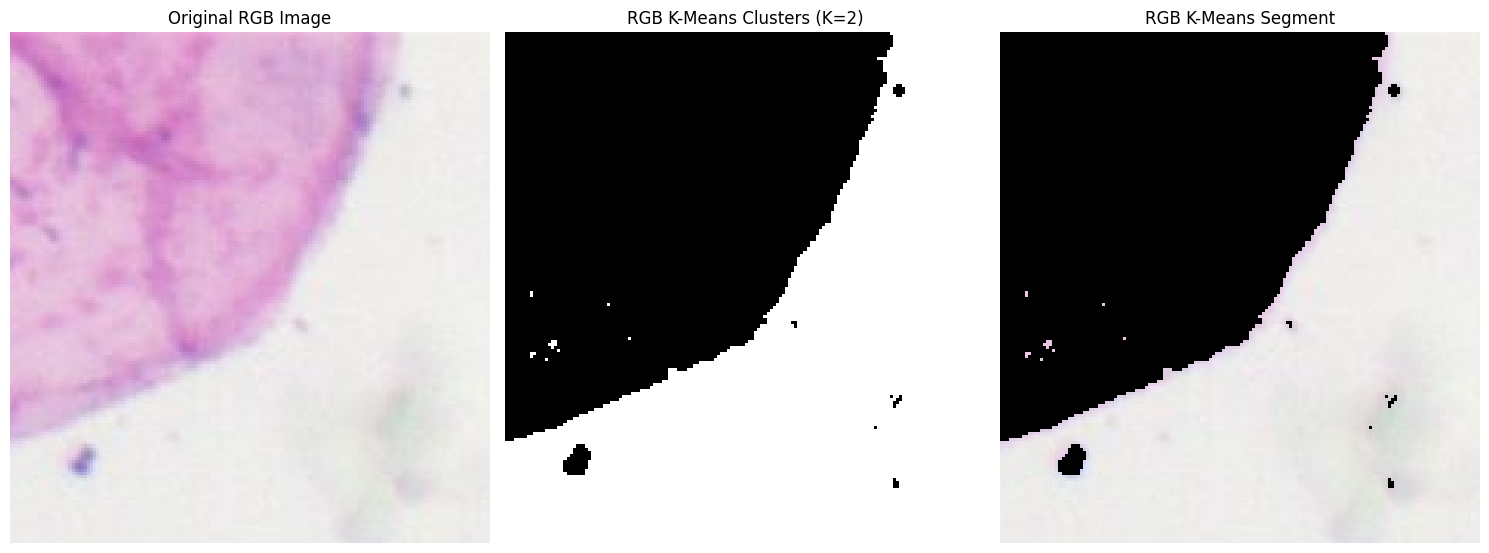

In [14]:
image_path_single_cell = 'single_cell.png'

# K Means RGB
print("Applying K-Means to RGB image")
rgb_image = cv2.imread(image_path_single_cell)


rgb_image = cv2.cvtColor(rgb_image, cv2.COLOR_BGR2RGB) # Convert BGR to RGB

h, w, c = rgb_image.shape
data_rgb = rgb_image.reshape((h * w, c)).astype(np.float32) # Reshape for K-Means

K_rgb = 2
mu_rgb_initial = np.array([[100, 100, 100], [200, 200, 200]], dtype=np.float32)
maxIteration = 100

cluster_assignments_rgb = my_k_means(data_rgb, K_rgb, mu_rgb_initial, maxIteration)

# Reshape cluster assignments back to image dimensions
segmentation_mask_rgb = cluster_assignments_rgb.reshape(h, w)

# Visualize RGB results
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(rgb_image)
plt.title('Original RGB Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(segmentation_mask_rgb, cmap='gray')
plt.title(f'RGB K-Means Clusters (K={K_rgb})')
plt.axis('off')

# Create segmented images based on clusters
segmented_image_rgb_0 = np.zeros_like(rgb_image)
segmented_image_rgb_1 = np.zeros_like(rgb_image)

segmented_image_rgb_0[segmentation_mask_rgb == 0] = rgb_image[segmentation_mask_rgb == 0]
segmented_image_rgb_1[segmentation_mask_rgb == 1] = rgb_image[segmentation_mask_rgb == 1]

plt.subplot(1, 3, 3)
# Display one of the segments
plt.imshow(segmented_image_rgb_1)
plt.title('RGB K-Means Segment')
plt.axis('off')

plt.tight_layout()
plt.show()


Applying K-Means to Grayscale image...
K-means converged after 8 iterations.


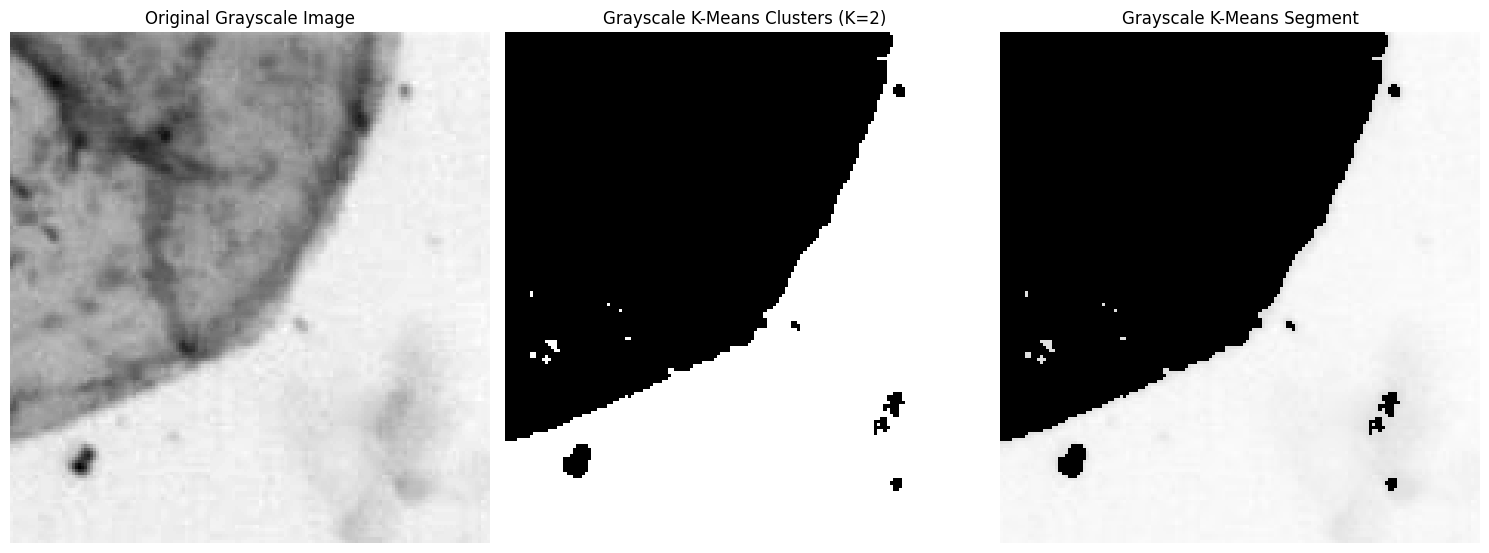

In [18]:
# K-Means on Grayscale image
print("\nApplying K-Means to Grayscale image...")
gray_image = cv2.imread(image_path_single_cell, cv2.IMREAD_GRAYSCALE)


h, w = gray_image.shape
data_gray = gray_image.reshape((h * w, 1)).astype(np.float32) # Reshape for K-Means (1 feature per pixel)

K_gray = 2
mu_gray_initial = np.array([[100], [200]], dtype=np.float32)
maxIteration = 100

cluster_assignments_gray = my_k_means(data_gray, K_gray, mu_gray_initial, maxIteration)

# Reshape cluster assignments back to image dimensions
segmentation_mask_gray = cluster_assignments_gray.reshape(h, w)

# Visualize Grayscale results
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(gray_image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(segmentation_mask_gray, cmap='gray')
plt.title(f'Grayscale K-Means Clusters (K={K_gray})')
plt.axis('off')

# Create segmented images based on clusters
segmented_image_gray_0 = np.zeros_like(gray_image)
segmented_image_gray_1 = np.zeros_like(gray_image)

segmented_image_gray_0[segmentation_mask_gray == 0] = gray_image[segmentation_mask_gray == 0]
segmented_image_gray_1[segmentation_mask_gray == 1] = gray_image[segmentation_mask_gray == 1]

plt.subplot(1, 3, 3)
# Display one of the segments
plt.imshow(segmented_image_gray_1, cmap='gray')
plt.title('Grayscale K-Means Segment')
plt.axis('off')

plt.tight_layout()
plt.show()

# 3. Superpixel-based Method
**Exercise 3.1 (10 points)**
- Apply skiimage.segmentation.slic() to RGB image "single_cell.png". Visualize the generated superpixels by calling skiimage.segmentation.mark_boundaries().

- Apply the developed K-means clustering algorithm to clustering the generated superpixels for $K=2$ (background and foreground). Suggested approach: consider that we have in total $N$ superpixels. For each superpixel $i$, $i\in\{1, ..., N\}$, denote $f_i=(R_i, G_i, B_i, x_i, y_i)^T \in \mathbb{R}^5$ as its feature array. $R_i$, $G_i$, $B_i$ refer to the average value of each channel for all pixels inside the superpixel $i$. $x_i, y_i$ refer to the central point of the superpixel $i$. Apply K-means clustering to cluster $f_1$, ..., $f_N$.

- Visualize the clustering results of superpixels, i.e. show the background and foreground respectively.

Note that one may need to start K-means algorithm for multiple times from different initial points in order to avoid local optimality.


Generating superpixels with SLIC
Generated 91 superpixels.


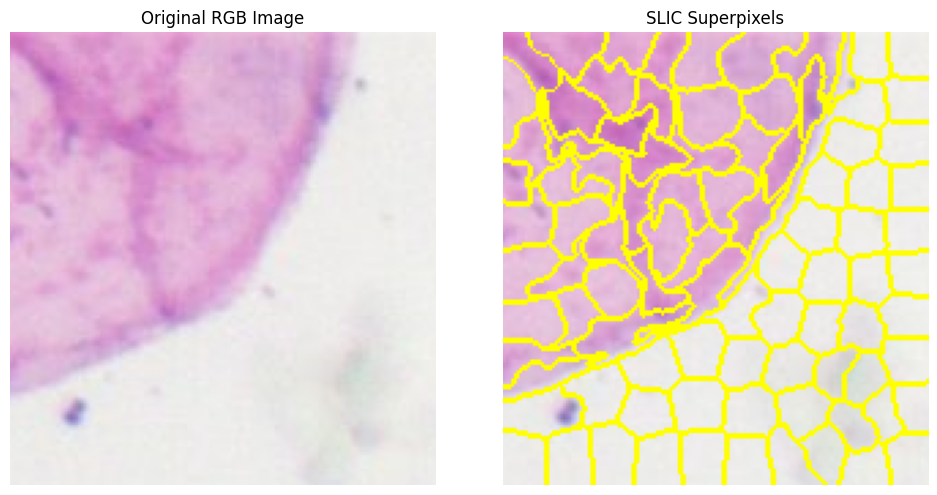

Extracted features for 91 superpixels, each with 5 features.
Applying K-Means to superpixel features with K=2...
K-means converged after 2 iterations.


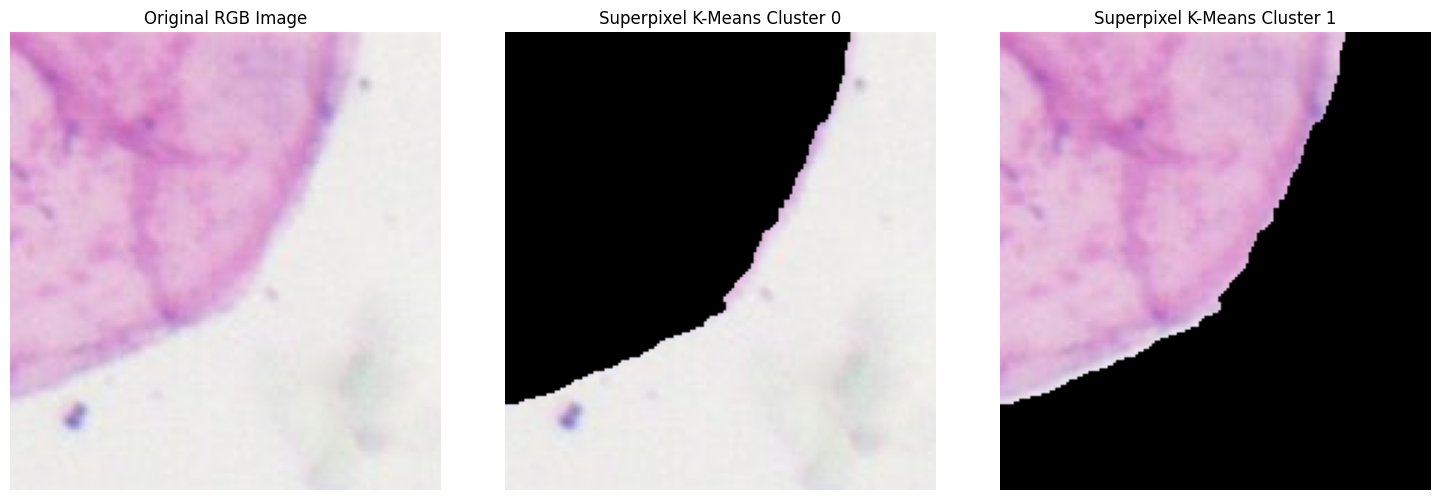

In [19]:
# Load the image
image_path_single_cell = '/content/single_cell.png'
rgb_image = cv2.imread(image_path_single_cell)


rgb_image = cv2.cvtColor(rgb_image, cv2.COLOR_BGR2RGB) # Convert BGR to RGB


#  Apply SLIC to generate superpixels
print("Generating superpixels with SLIC")
# n_segments: approximate number of superpixels
# compactness: balances color proximity and space proximity. Higher values give more compact, more square superpixels.
# sigma: width of Gaussian smoothing kernel for pre-processing.
segments = slic(rgb_image, n_segments=100, compactness=10, sigma=1, start_label=0)
num_superpixels = segments.max() + 1
print(f"Generated {num_superpixels} superpixels.")

# Visualize the generated superpixels
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title('Original RGB Image')
plt.axis('off')

plt.subplot(1, 2, 2)
# Mark boundaries of the superpixels
plt.imshow(mark_boundaries(rgb_image, segments))
plt.title('SLIC Superpixels')
plt.axis('off')
plt.tight_layout()
plt.show()


#  Extract features for each superpixel
# Features: (R_mean, G_mean, B_mean, x_centroid, y_centroid)
features_superpixels = []
for i in range(num_superpixels):
    mask = (segments == i)

    # Get pixels belonging to the current superpixel
    pixels_in_superpixel = rgb_image[mask]

    # Calculate mean RGB values
    mean_rgb = np.mean(pixels_in_superpixel, axis=0)

    # Calculate centroid coordinates
    coords = np.argwhere(mask)
    y_coords, x_coords = coords[:, 0], coords[:, 1]
    centroid_x = np.mean(x_coords)
    centroid_y = np.mean(y_coords)

    # Combine features
    features_superpixels.append(np.concatenate((mean_rgb, [centroid_x, centroid_y])))

data_superpixels = np.array(features_superpixels, dtype=np.float32)
print(f"Extracted features for {data_superpixels.shape[0]} superpixels, each with {data_superpixels.shape[1]} features.")


# Apply K-Means clustering to superpixel features
K_superpixels = 2
maxIteration = 100

# Initial centroids for 5D features.
np.random.seed(42)
initial_indices = np.random.choice(num_superpixels, K_superpixels, replace=False)
mu_superpixels_initial = data_superpixels[initial_indices].copy()

print(f"Applying K-Means to superpixel features with K={K_superpixels}...")
cluster_assignments_superpixels = my_k_means(data_superpixels, K_superpixels, mu_superpixels_initial, maxIteration)


#Visualize the clustering results of superpixels
segmented_superpixel_image_0 = np.zeros_like(rgb_image, dtype=np.uint8)
segmented_superpixel_image_1 = np.zeros_like(rgb_image, dtype=np.uint8)

for i in range(num_superpixels):
    mask = (segments == i)
    if cluster_assignments_superpixels[i] == 0:
        segmented_superpixel_image_0[mask] = rgb_image[mask]
    else:
        segmented_superpixel_image_1[mask] = rgb_image[mask]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(rgb_image)
plt.title('Original RGB Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(segmented_superpixel_image_0)
plt.title('Superpixel K-Means Cluster 0')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(segmented_superpixel_image_1)
plt.title('Superpixel K-Means Cluster 1')
plt.axis('off')

plt.tight_layout()
plt.show()